In [1]:
import pandas as pd

In [2]:
# 1. Load the dataset
df = pd.read_csv('StudentsPerformance.csv')

In [7]:
# 2. Basic dimensions
print("Dataset Shape:",df.shape[0],"rows", df.shape[1], "columns")

Dataset Shape: 1000 rows 8 columns


In [6]:
# 3. Data types and non-null counts
print("Dataset Info:")
df.info()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [10]:
# 4. Check for missing values explicitly
print("Missing Values per Column:")
df.isnull().sum()

Missing Values per Column:


gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

In [9]:
# 5. Check for duplicate rows
print("Total Duplicate Rows:",df.duplicated().sum())

Total Duplicate Rows: 0


In [11]:
# 6. Preview the first 3 rows
print("First 3 Rows:")
df.head(3)

First 3 Rows:


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93


In [14]:
df

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,88,99,95
996,male,group C,high school,free/reduced,none,62,55,55
997,female,group C,high school,free/reduced,completed,59,71,65
998,female,group D,some college,standard,completed,68,78,77


# data cleaning


In [13]:
# 1. Rename columns to standard Python snake_case
df.columns = [col.replace('/', '_').replace(' ', '_') for col in df.columns]
df

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,88,99,95
996,male,group C,high school,free/reduced,none,62,55,55
997,female,group C,high school,free/reduced,completed,59,71,65
998,female,group D,some college,standard,completed,68,78,77


In [17]:
# 2. Create the target variable: average_score
df['average_score'] = df[['math_score', 'reading_score', 'writing_score']].mean(axis=1)
df

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,average_score
0,female,group B,bachelor's degree,standard,none,72,72,74,72.666667
1,female,group C,some college,standard,completed,69,90,88,82.333333
2,female,group B,master's degree,standard,none,90,95,93,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,49.333333
4,male,group C,some college,standard,none,76,78,75,76.333333
...,...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,88,99,95,94.000000
996,male,group C,high school,free/reduced,none,62,55,55,57.333333
997,female,group C,high school,free/reduced,completed,59,71,65,65.000000
998,female,group D,some college,standard,completed,68,78,77,74.333333


In [19]:
# 3. Round the average to 2 decimal places for cleaner data
df['average_score'] = df['average_score'].round(2)
df

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,average_score
0,female,group B,bachelor's degree,standard,none,72,72,74,72.67
1,female,group C,some college,standard,completed,69,90,88,82.33
2,female,group B,master's degree,standard,none,90,95,93,92.67
3,male,group A,associate's degree,free/reduced,none,47,57,44,49.33
4,male,group C,some college,standard,none,76,78,75,76.33
...,...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,88,99,95,94.00
996,male,group C,high school,free/reduced,none,62,55,55,57.33
997,female,group C,high school,free/reduced,completed,59,71,65,65.00
998,female,group D,some college,standard,completed,68,78,77,74.33


In [20]:
# 4. Verify the changes
print("Updated Columns:\n", df.columns.tolist())
print("\nTarget Variable Preview:")
df[['math_score', 'reading_score', 'writing_score', 'average_score']].head()

Updated Columns:
 ['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch', 'test_preparation_course', 'math_score', 'reading_score', 'writing_score', 'average_score']

Target Variable Preview:


,math_score,reading_score,writing_score,average_score
0,72,72,74,72.67
1,69,90,88,82.33
2,90,95,93,92.67
3,47,57,44,49.33
4,76,78,75,76.33


# EDA

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

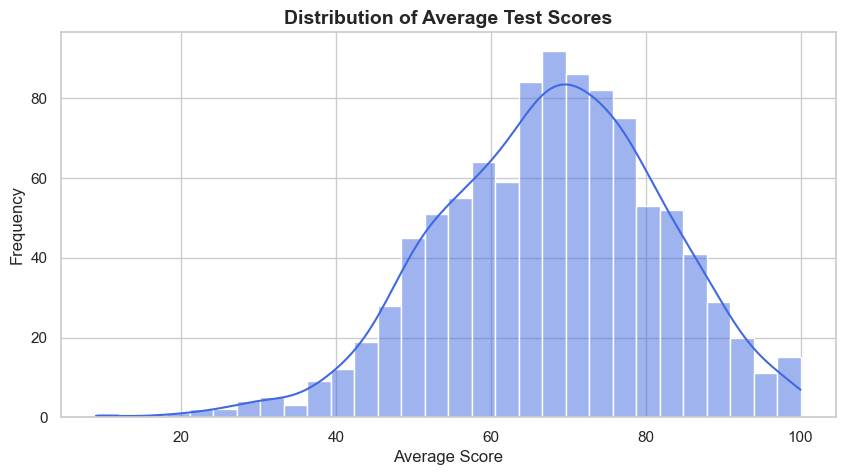

In [24]:
# 1. Target Variable Distribution (Histogram)
plt.figure(figsize=(10, 5))
sns.histplot(df['average_score'], kde=True, bins=30, color='royalblue')
plt.title('Distribution of Average Test Scores', fontsize=14, fontweight='bold')
plt.xlabel('Average Score', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.show()

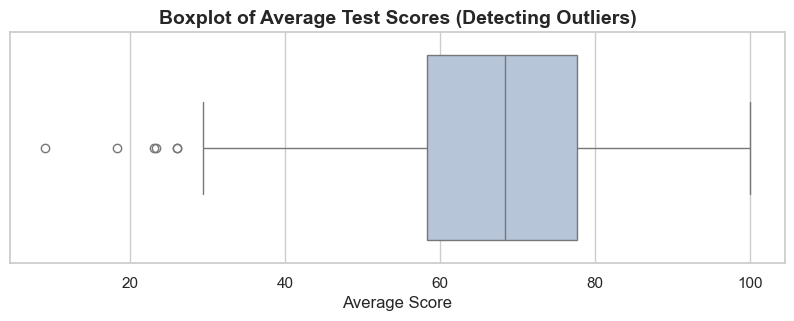

In [25]:
# 2. Target Variable Outliers (Boxplot)
plt.figure(figsize=(10, 3))
sns.boxplot(x=df['average_score'], color='lightsteelblue')
plt.title('Boxplot of Average Test Scores (Detecting Outliers)', fontsize=14, fontweight='bold')
plt.xlabel('Average Score', fontsize=12)
plt.show()

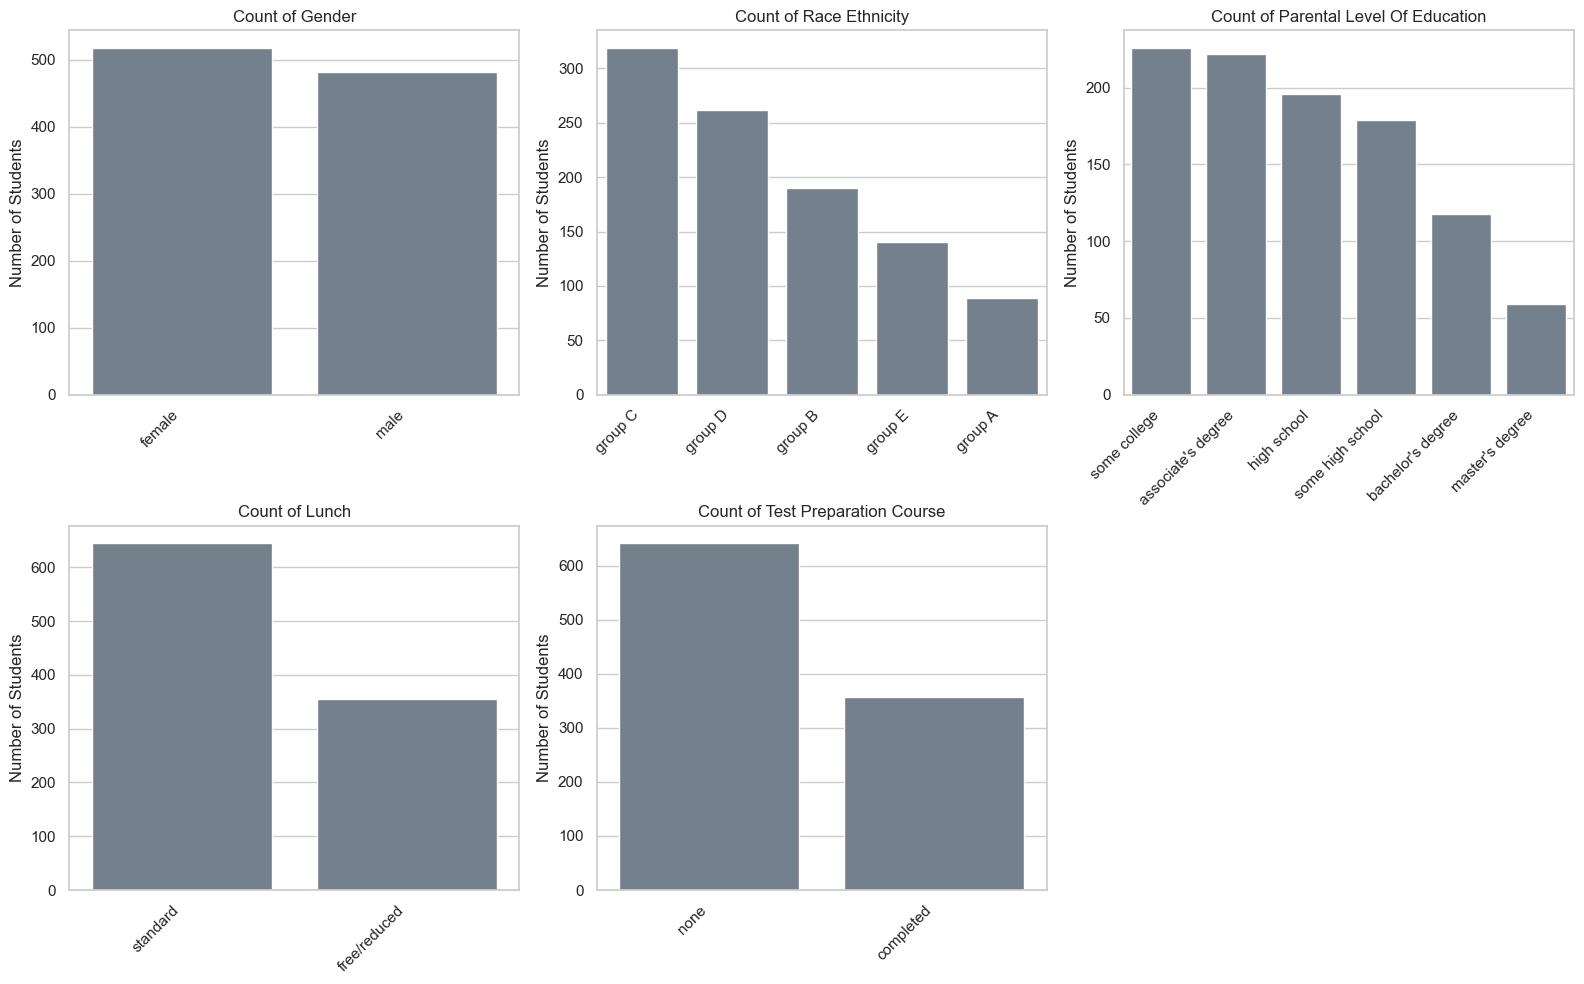

In [26]:
# 3. Categorical Variables Overview (Countplots)
categorical_cols = ['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch', 'test_preparation_course']

# Create a figure with subplots (2 rows, 3 columns)
plt.figure(figsize=(16, 10))
for i, col in enumerate(categorical_cols, 1):
    plt.subplot(2, 3, i)
    # Order the bars from highest to lowest count for readability
    order = df[col].value_counts().index
    sns.countplot(data=df, x=col, order=order, color='slategray')
    plt.title(f'Count of {col.replace("_", " ").title()}', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.ylabel('Number of Students')
    plt.xlabel('')

plt.tight_layout()
plt.show()

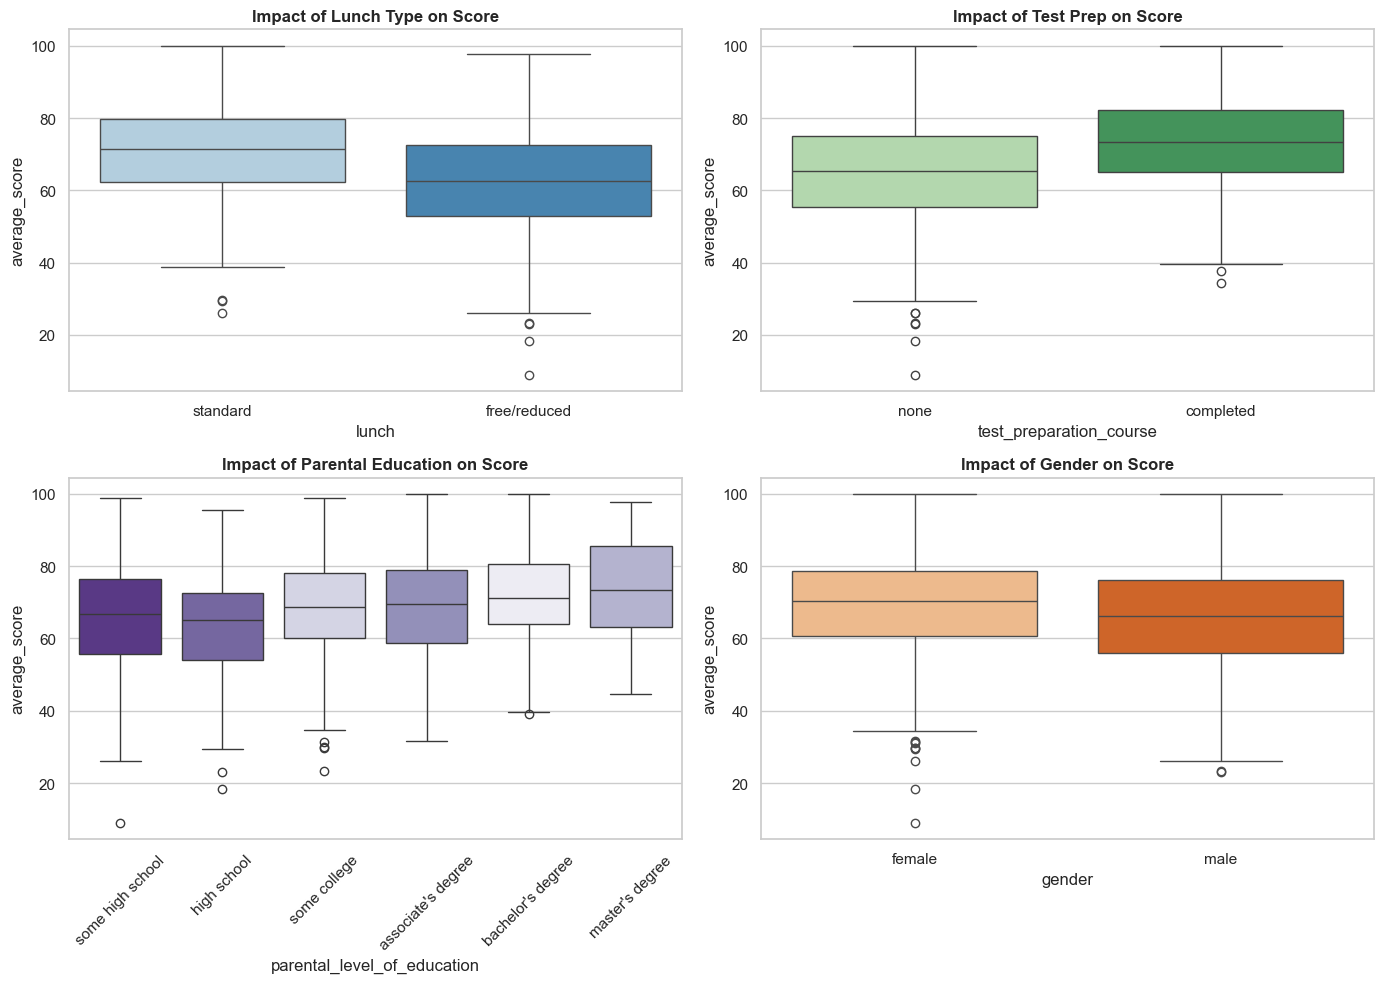

In [31]:
# Bivariate Analysis: Features vs. Target Variable
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Lunch vs Average Score
sns.boxplot(data=df, x='lunch', y='average_score', ax=axes[0,0], palette='Blues', hue='lunch', legend=False)
axes[0,0].set_title('Impact of Lunch Type on Score', fontsize=12, fontweight='bold')

# 2. Test Prep vs Average Score
sns.boxplot(data=df, x='test_preparation_course', y='average_score', ax=axes[0,1], palette='Greens', hue='test_preparation_course', legend=False)
axes[0,1].set_title('Impact of Test Prep on Score', fontsize=12, fontweight='bold')

# 3. Parental Education vs Average Score (Ordered logically)
edu_order = ["some high school", "high school", "some college", 
             "associate's degree", "bachelor's degree", "master's degree"]
sns.boxplot(data=df, x='parental_level_of_education', y='average_score', 
            order=edu_order, ax=axes[1,0], palette='Purples', hue='parental_level_of_education', legend=False)
axes[1,0].set_title('Impact of Parental Education on Score', fontsize=12, fontweight='bold')
axes[1,0].tick_params(axis='x', rotation=45)

# 4. Gender vs Average Score
sns.boxplot(data=df, x='gender', y='average_score', ax=axes[1,1], palette='Oranges', hue='gender', legend=False)
axes[1,1].set_title('Impact of Gender on Score', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

# FEATURE ENGINEERING & SELECTION

In [34]:
# 1. Drop the original test scores to PREVENT DATA LEAKAGE
columns_to_drop = ['math_score', 'reading_score', 'writing_score']
df_model = df.drop(columns=columns_to_drop)
df

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,average_score
0,female,group B,bachelor's degree,standard,none,72,72,74,72.67
1,female,group C,some college,standard,completed,69,90,88,82.33
2,female,group B,master's degree,standard,none,90,95,93,92.67
3,male,group A,associate's degree,free/reduced,none,47,57,44,49.33
4,male,group C,some college,standard,none,76,78,75,76.33
...,...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,88,99,95,94.00
996,male,group C,high school,free/reduced,none,62,55,55,57.33
997,female,group C,high school,free/reduced,completed,59,71,65,65.00
998,female,group D,some college,standard,completed,68,78,77,74.33


In [36]:
# 2. Separate Features (X) and Target (y)
X = df_model.drop(columns=['average_score'])
y = df_model['average_score']
df

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,average_score
0,female,group B,bachelor's degree,standard,none,72,72,74,72.67
1,female,group C,some college,standard,completed,69,90,88,82.33
2,female,group B,master's degree,standard,none,90,95,93,92.67
3,male,group A,associate's degree,free/reduced,none,47,57,44,49.33
4,male,group C,some college,standard,none,76,78,75,76.33
...,...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,88,99,95,94.00
996,male,group C,high school,free/reduced,none,62,55,55,57.33
997,female,group C,high school,free/reduced,completed,59,71,65,65.00
998,female,group D,some college,standard,completed,68,78,77,74.33


In [37]:
X.columns.tolist()
X.head(3)

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course
0,female,group B,bachelor's degree,standard,none
1,female,group C,some college,standard,completed
2,female,group B,master's degree,standard,none


# TRAIN/TEST SPLIT & DATA PREPROCESSING

In [38]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

In [47]:
# PHASE 6: Train/Test Split
# We use a 20% test size (standard for datasets around 1000 rows).
# random_state=42 ensures we get the exact same split every time we run the code.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (800, 5)
Testing data shape: (200, 5)


In [48]:
# PHASE 5: Data Preprocessing
# Define our categorical columns
categorical_features = X.columns.tolist()

# Create a professional ColumnTransformer
# drop='first' prevents multicollinearity (e.g. if female is 0, it knows male is 1. We don't need two columns for gender)
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_features)
    ]
)

In [49]:
# Fit ONLY on the training data, then transform both
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Convert the output array back to a dataframe just so we can see what happened
feature_names = preprocessor.get_feature_names_out(categorical_features)
X_train_df = pd.DataFrame(X_train_processed, columns=feature_names)

print("Preprocessed Training Data (First 3 rows):")
display(X_train_df.head(3))

Preprocessed Training Data (First 3 rows):


,cat__gender_male,cat__race_ethnicity_group B,cat__race_ethnicity_group C,cat__race_ethnicity_group D,cat__race_ethnicity_group E,cat__parental_level_of_education_bachelor's degree,cat__parental_level_of_education_high school,cat__parental_level_of_education_master's degree,cat__parental_level_of_education_some college,cat__parental_level_of_education_some high school,cat__lunch_standard,cat__test_preparation_course_none
0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0
1,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0


# BASELINE MODEL

In [50]:
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

In [52]:
# 1. Initialize the "dumb" model to just guess the mean average_score every time
baseline_model = DummyRegressor(strategy='mean')

# 2. "Train" the baseline model (it just calculates the mean of y_train)
baseline_model.fit(X_train_processed, y_train)

# 3. Make predictions on the unseen test data
y_pred_baseline = baseline_model.predict(X_test_processed)

# 4. Evaluate the baseline model
baseline_mae = mean_absolute_error(y_test, y_pred_baseline)
baseline_rmse = np.sqrt(mean_squared_error(y_test, y_pred_baseline))

print("BASELINE MODEL PERFORMANCE")
print(f"Mean Absolute Error (MAE): {baseline_mae:.2f} points")
print(f"Root Mean Squared Error (RMSE): {baseline_rmse:.2f} points")

BASELINE MODEL PERFORMANCE
Mean Absolute Error (MAE): 11.63 points
Root Mean Squared Error (RMSE): 14.78 points


# MODEL TRAINING AND EVALUATION

In [53]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

In [54]:
# 1. Initialize the models
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42)
}

# 2. Dictionary to store the results
results = {}

In [55]:
# 3. Train and evaluate each model in a loop
print("--- MODEL EVALUATION RESULTS ---\n")
for name, model in models.items():
    # Train the model
    model.fit(X_train_processed, y_train)
    
    # Make predictions on the test set
    y_pred = model.predict(X_test_processed)
    
    # Calculate metrics
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    
    # Store results
    results[name] = {'MAE': mae, 'RMSE': rmse}
    
    # Print the results
    print(f"** {name} **")
    print(f"MAE:  {mae:.2f} points")
    print(f"RMSE: {rmse:.2f} points\n")

--- MODEL EVALUATION RESULTS ---

** Linear Regression **
MAE:  10.49 points
RMSE: 13.40 points

** Random Forest **
MAE:  11.48 points
RMSE: 14.78 points

** Gradient Boosting **
MAE:  10.85 points
RMSE: 14.00 points



# CROSS-VALIDATION

In [56]:
from sklearn.model_selection import cross_val_score
# 1. We need to preprocess the ENTIRE feature set (X) for Cross-Validation
X_processed_full = preprocessor.fit_transform(X)

In [57]:
# 2. Define the models we want to cross-validate
lin_reg = LinearRegression()
gb_reg = GradientBoostingRegressor(random_state=42)

# 3. Perform 5-Fold Cross Validation (scoring uses Negative MAE by default in sklearn)
lin_reg_cv_scores = cross_val_score(lin_reg, X_processed_full, y, cv=5, scoring='neg_mean_absolute_error')
gb_cv_scores = cross_val_score(gb_reg, X_processed_full, y, cv=5, scoring='neg_mean_absolute_error')

In [58]:
# 4. Convert negative scores back to positive and calculate the mean
lin_reg_cv_mae = -lin_reg_cv_scores.mean()
gb_cv_mae = -gb_cv_scores.mean()

print("--- 5-FOLD CROSS-VALIDATION RESULTS ---")
print(f"Linear Regression Average MAE: {lin_reg_cv_mae:.2f} points")
print(f"Gradient Boosting Average MAE: {gb_cv_mae:.2f} points")

--- 5-FOLD CROSS-VALIDATION RESULTS ---
Linear Regression Average MAE: 10.14 points
Gradient Boosting Average MAE: 10.47 points


# PREDICTION SYSTEM & MODEL SAVING

In [59]:
from sklearn.pipeline import Pipeline
import joblib

In [60]:
# 1. Build and Train the Final Pipeline
# Bundle the preprocessor and the chosen model together
final_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

# Train the pipeline on the original text-based training data (X_train, NOT X_train_processed)
final_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [65]:
# 2. Save the Model
joblib.dump(final_pipeline, 'student_performance_model.pkl')
print("Pipeline successfully saved as 'student_performance_model.pkl")

Pipeline successfully saved as 'student_performance_model.pkl


In [63]:
# 3. Test the Prediction System
# Load the model from disk (simulating what a web app would do)
loaded_model = joblib.load('student_performance_model.pkl')

# Create a raw input profile for a new student
new_student = pd.DataFrame({
    'gender': ['female'],
    'race_ethnicity': ['group C'],
    'parental_level_of_education': ["bachelor's degree"],
    'lunch': ['standard'],
    'test_preparation_course': ['completed']
})

# Make a prediction
predicted_score = loaded_model.predict(new_student)
print("--- PREDICTION SYSTEM TEST ---")
print("Student Profile: Female, Group C, Bachelor's Parent, Standard Lunch, Completed Prep")
print(f"Predicted Average Score: {predicted_score[0]:.2f}")

--- PREDICTION SYSTEM TEST ---
Student Profile: Female, Group C, Bachelor's Parent, Standard Lunch, Completed Prep
Predicted Average Score: 81.90
